# 05 - EDA from Scraped CSVs


In [1]:
# pandas is used for tables and calculations.
# matplotlib is used for simple inline notebook charts.
!pip -q install pandas matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Force charts to render inside the notebook output cells.
# Colab normally does this by default, but this line makes the intention explicit.
%matplotlib inline

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.rcParams["figure.figsize"] = (10, 5)

# Read directly from Colab's content directory
DATA_DIR = Path("/content/data")

print("Using data folder:", DATA_DIR.resolve())

Using data folder: /content/data


## 1. Load the CSV Files

Each CSV came from one scraping notebook:

- SmartCentres PDFs and website distributions
- yfinance market data
- Bank of Canada macro data
- WOWA competitor table

This notebook starts from those CSVs only.

In [3]:
stock_prices = pd.read_csv(DATA_DIR / "yfinance_stock_prices.csv")
company_profile = pd.read_csv(DATA_DIR / "yfinance_company_profile.csv")
yfinance_dividends = pd.read_csv(DATA_DIR / "yfinance_dividends.csv")
financials = pd.read_csv(DATA_DIR / "smartcentres_financials_from_pdfs.csv")
properties = pd.read_csv(DATA_DIR / "smartcentres_properties.csv")
smartcentres_distributions = pd.read_csv(DATA_DIR / "smartcentres_distributions.csv")
macro = pd.read_csv(DATA_DIR / "bank_of_canada_macro.csv")
competitors = pd.read_csv(DATA_DIR / "wowa_competitors.csv")

loaded_files = pd.DataFrame([
    {"DataFrame": "stock_prices", "Rows": len(stock_prices), "Columns": len(stock_prices.columns)},
    {"DataFrame": "company_profile", "Rows": len(company_profile), "Columns": len(company_profile.columns)},
    {"DataFrame": "yfinance_dividends", "Rows": len(yfinance_dividends), "Columns": len(yfinance_dividends.columns)},
    {"DataFrame": "financials", "Rows": len(financials), "Columns": len(financials.columns)},
    {"DataFrame": "properties", "Rows": len(properties), "Columns": len(properties.columns)},
    {"DataFrame": "smartcentres_distributions", "Rows": len(smartcentres_distributions), "Columns": len(smartcentres_distributions.columns)},
    {"DataFrame": "macro", "Rows": len(macro), "Columns": len(macro.columns)},
    {"DataFrame": "competitors", "Rows": len(competitors), "Columns": len(competitors.columns)},
])
display(loaded_files)

,DataFrame,Rows,Columns
0,stock_prices,6930,9
1,company_profile,5,14
2,yfinance_dividends,66,5
3,financials,169,9
4,properties,50,9
5,smartcentres_distributions,6,7
6,macro,5953,5
7,competitors,5,10


## 2. Stock Performance

Stock analysis uses `yfinance_stock_prices.csv`.

Finance meaning:
- Adjusted close is used because it is better for return analysis.
- Monthly returns show whether the stock was rising or falling month to month.
- Indexed performance lets different REITs be compared from the same starting value of 100.

In [4]:
SMARTCENTRES_TICKER = "SRU-UN.TO"

stock_prices["Date"] = pd.to_datetime(stock_prices["Date"], errors="coerce", utc=True).dt.tz_convert(None)
stock_prices = stock_prices.sort_values(["ticker", "Date"]).copy()
stock_prices["daily_return"] = stock_prices.groupby("ticker")["Adj Close"].pct_change()
stock_prices["indexed_price"] = stock_prices.groupby("ticker")["Adj Close"].transform(lambda s: s / s.iloc[0] * 100)

smart_stock = stock_prices[stock_prices["ticker"] == SMARTCENTRES_TICKER].copy()
smart_stock["ma_50"] = smart_stock["Adj Close"].rolling(50).mean()
smart_stock["ma_200"] = smart_stock["Adj Close"].rolling(200).mean()

monthly_prices = (
    stock_prices.set_index("Date")
    .groupby("ticker")
    .resample("ME")["Adj Close"]
    .last()
    .reset_index()
    .sort_values(["ticker", "Date"])
)
monthly_prices["monthly_return"] = monthly_prices.groupby("ticker")["Adj Close"].pct_change()
monthly_prices["year"] = monthly_prices["Date"].dt.year

annual_returns = (
    monthly_prices.dropna(subset=["monthly_return"])
    .assign(one_plus_return=lambda df: 1 + df["monthly_return"])
    .groupby(["ticker", "year"], as_index=False)["one_plus_return"]
    .prod()
)
annual_returns["annual_return"] = annual_returns["one_plus_return"] - 1
annual_returns = annual_returns.drop(columns=["one_plus_return"])
display(annual_returns.head(10))

,ticker,year,annual_return
0,AP-UN.TO,2021,0.256006
1,AP-UN.TO,2022,-0.386166
2,AP-UN.TO,2023,-0.121395
3,AP-UN.TO,2024,-0.059192
4,AP-UN.TO,2025,-0.134749
5,AP-UN.TO,2026,-0.205332
6,CHP-UN.TO,2021,0.231928
7,CHP-UN.TO,2022,0.024101
8,CHP-UN.TO,2023,-0.001223
9,CHP-UN.TO,2024,0.011153


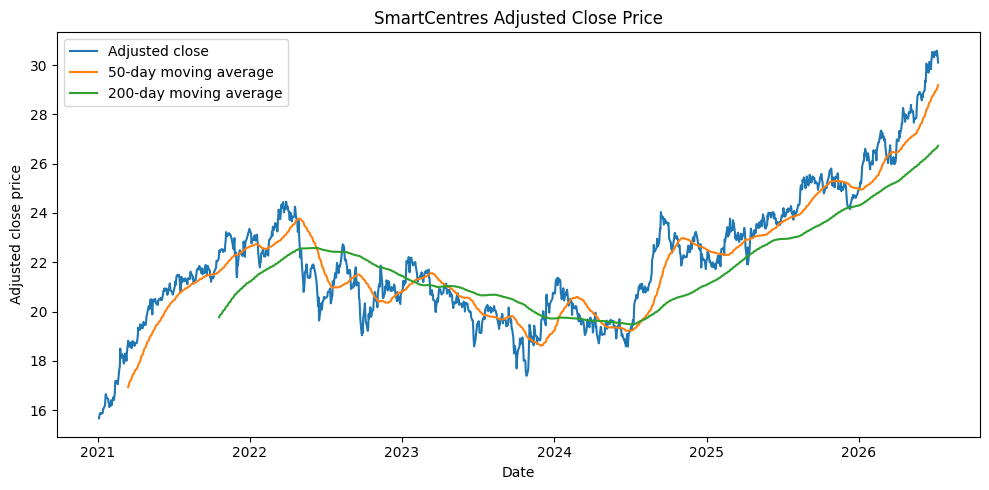

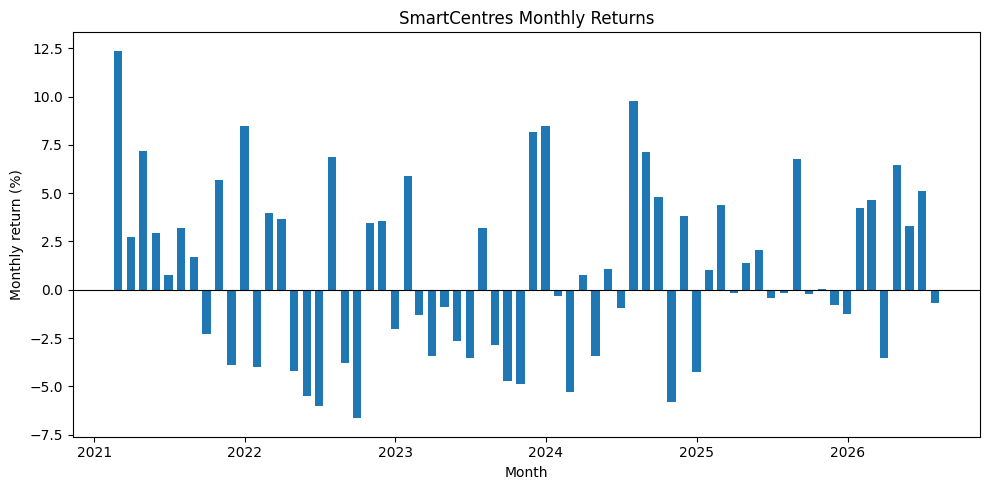

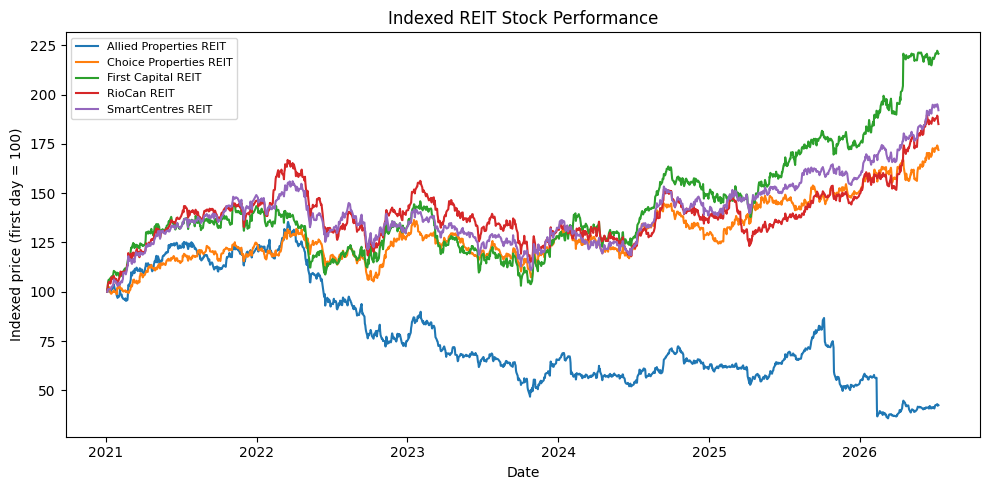

In [5]:
plt.figure()
plt.plot(smart_stock["Date"], smart_stock["Adj Close"], label="Adjusted close")
plt.plot(smart_stock["Date"], smart_stock["ma_50"], label="50-day moving average")
plt.plot(smart_stock["Date"], smart_stock["ma_200"], label="200-day moving average")
plt.title("SmartCentres Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Adjusted close price")
plt.legend()
plt.tight_layout()
plt.show()

smart_monthly = monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER].dropna(subset=["monthly_return"])
plt.figure()
plt.bar(smart_monthly["Date"], smart_monthly["monthly_return"] * 100, width=20)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("SmartCentres Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Monthly return (%)")
plt.tight_layout()
plt.show()

plt.figure()
for ticker, group in stock_prices.groupby("ticker"):
    label = group["company_name"].iloc[0]
    plt.plot(group["Date"], group["indexed_price"], label=label)
plt.title("Indexed REIT Stock Performance")
plt.xlabel("Date")
plt.ylabel("Indexed price (first day = 100)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Dividends and Distributions

Dividend analysis uses `yfinance_dividends.csv` for the longer history.

The SmartCentres website distribution CSV is still useful as an official source, but the visible company table only covers the current selected year. For annual trend analysis, yfinance gives a longer monthly history.

,year,payment_count,annual_distribution_per_unit,average_payment,distribution_growth,is_partial_year
0,2021,12,1.848,0.154,NaN,False
1,2022,12,1.848,0.154,0.0,False
2,2023,12,1.848,0.154,0.0,False
3,2024,12,1.848,0.154,0.0,False
4,2025,12,1.848,0.154,0.0,False
5,2026,6,0.924,0.154,-0.5,True


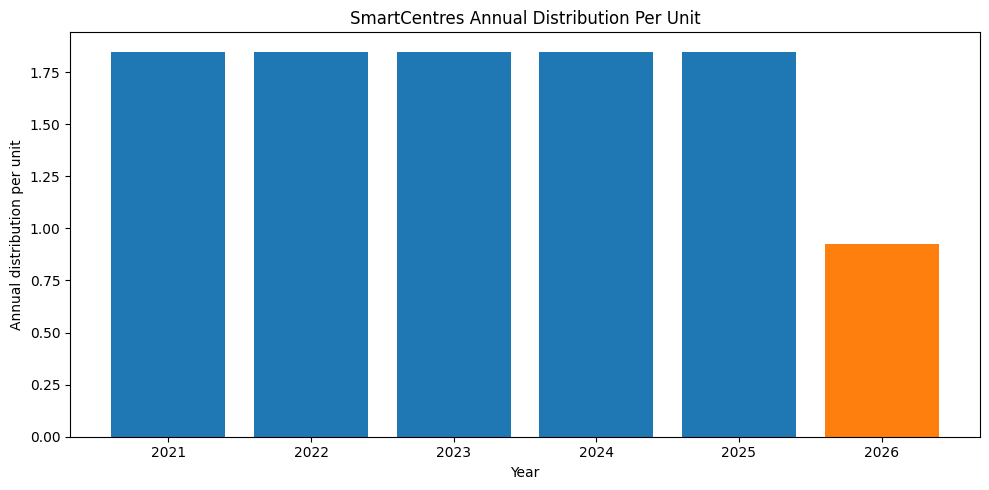

In [6]:
yfinance_dividends["dividend_amount"] = pd.to_numeric(yfinance_dividends["dividend_amount"], errors="coerce")
yfinance_dividends["dividend_date"] = pd.to_datetime(yfinance_dividends["dividend_date"], errors="coerce", utc=True).dt.tz_convert(None)
yfinance_dividends["year"] = yfinance_dividends["dividend_date"].dt.year

annual_dividends = (
    yfinance_dividends.dropna(subset=["year", "dividend_amount"])
    .groupby("year", as_index=False)
    .agg(
        payment_count=("dividend_amount", "count"),
        annual_distribution_per_unit=("dividend_amount", "sum"),
        average_payment=("dividend_amount", "mean"),
    )
)
annual_dividends["distribution_growth"] = annual_dividends["annual_distribution_per_unit"].pct_change()
annual_dividends["is_partial_year"] = annual_dividends["payment_count"] < 12
display(annual_dividends)

colors = annual_dividends["is_partial_year"].map({True: "tab:orange", False: "tab:blue"})
plt.figure()
plt.bar(annual_dividends["year"].astype(str), annual_dividends["annual_distribution_per_unit"], color=colors)
plt.title("SmartCentres Annual Distribution Per Unit")
plt.xlabel("Year")
plt.ylabel("Annual distribution per unit")
plt.tight_layout()
plt.show()

## 4. Financial Performance from SmartCentres PDFs

These rows come from `smartcentres_financials_from_pdfs.csv`.

Important unit note:
SmartCentres financial statement values are often reported in **thousands of Canadian dollars**. For charts, this notebook converts those values into **CAD millions** so the scale is easier to read.

In [7]:
financials["period"] = pd.to_numeric(financials["period"], errors="coerce").astype("Int64")
financials["value_numeric"] = pd.to_numeric(financials["value_numeric"], errors="coerce")

financial_summary = (
    financials.dropna(subset=["period", "metric_or_line_item", "value_numeric"])
    .groupby(["metric_or_line_item", "period"], as_index=False)
    .agg(value=("value_numeric", "median"))
    .sort_values(["metric_or_line_item", "period"])
)
financial_summary["yoy_growth"] = financial_summary.groupby("metric_or_line_item")["value"].pct_change()

def metric_series(summary, metric_name):
    return summary[summary["metric_or_line_item"] == metric_name].dropna(subset=["period", "value"]).copy()

def thousands_to_millions(series):
    return pd.to_numeric(series, errors="coerce") / 1000

display(financial_summary.head(15))

,metric_or_line_item,period,value,yoy_growth
0,Adjusted Debt to Adjusted EBITDA,2023,9.6,NaN
1,Adjusted Debt to Adjusted EBITDA,2024,9.6,0.000000
2,Adjusted Debt to Adjusted EBITDA,2025,9.7,0.010417
3,Cash and cash equivalents,2021,62235.0,NaN
4,Cash and cash equivalents,2022,35255.0,-0.433518
5,Cash and cash equivalents,2023,34999.0,-0.007261
6,Cash and cash equivalents,2024,36218.5,0.034844
7,Cash and cash equivalents,2025,51551.0,0.423333
8,Cash flows provided by operating activities,2021,371624.0,NaN
9,Cash flows provided by operating activities,2022,370762.0,-0.002320


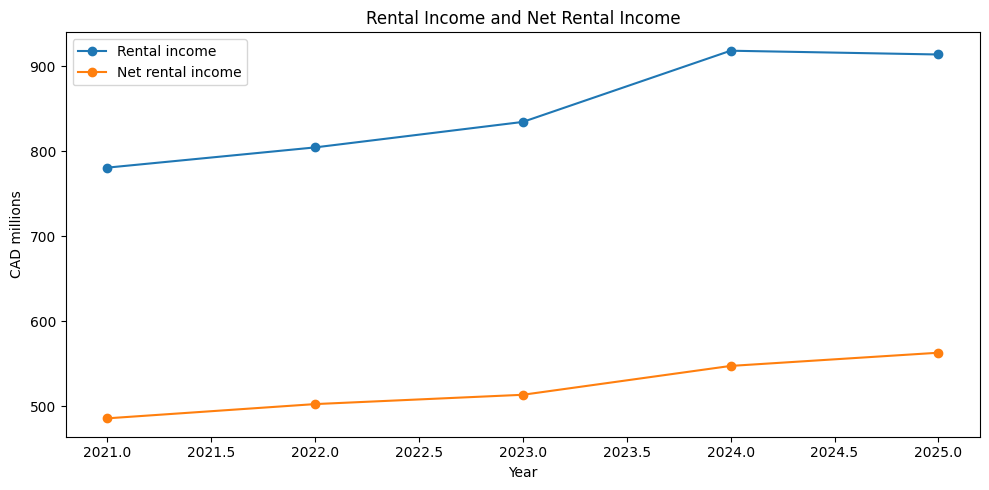

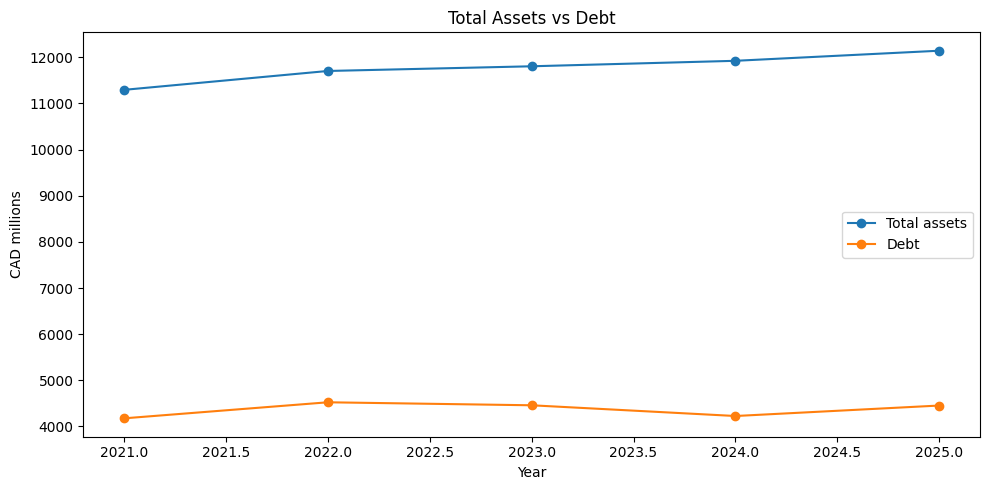

In [8]:
rental = metric_series(financial_summary, "Rentals from investment properties and other")
net_rental = metric_series(financial_summary, "Net rental income and other")
total_assets = metric_series(financial_summary, "Total assets")
debt = metric_series(financial_summary, "Debt")
operating_cash_flow = metric_series(financial_summary, "Cash flows provided by operating activities")
distributions_paid = metric_series(financial_summary, "Distributions paid on Trust Units")
net_income = metric_series(financial_summary, "Net income and comprehensive income")

plt.figure()
plt.plot(rental["period"], thousands_to_millions(rental["value"]), marker="o", label="Rental income")
plt.plot(net_rental["period"], thousands_to_millions(net_rental["value"]), marker="o", label="Net rental income")
plt.title("Rental Income and Net Rental Income")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(total_assets["period"], thousands_to_millions(total_assets["value"]), marker="o", label="Total assets")
plt.plot(debt["period"], thousands_to_millions(debt["value"]), marker="o", label="Debt")
plt.title("Total Assets vs Debt")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

,period,operating_cash_flow,distributions_paid,distributions_paid_abs,distributions_as_pct_of_operating_cash_flow,operating_cash_flow_cad_millions,distributions_paid_cad_millions
0,2021,371624.0,-267552.0,267552.0,71.995350,371.624,267.552
1,2022,370762.0,-267563.0,267563.0,72.165702,370.762,267.563
2,2023,330853.0,-267563.0,267563.0,80.870659,330.853,267.563
3,2024,374208.0,-267630.0,267630.0,71.519048,374.208,267.630
4,2025,377441.0,-267681.0,267681.0,70.919958,377.441,267.681


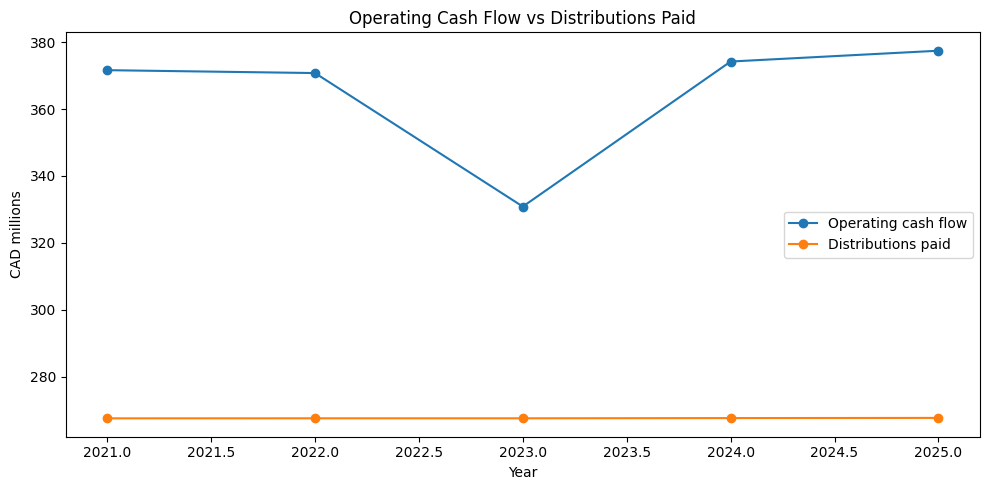

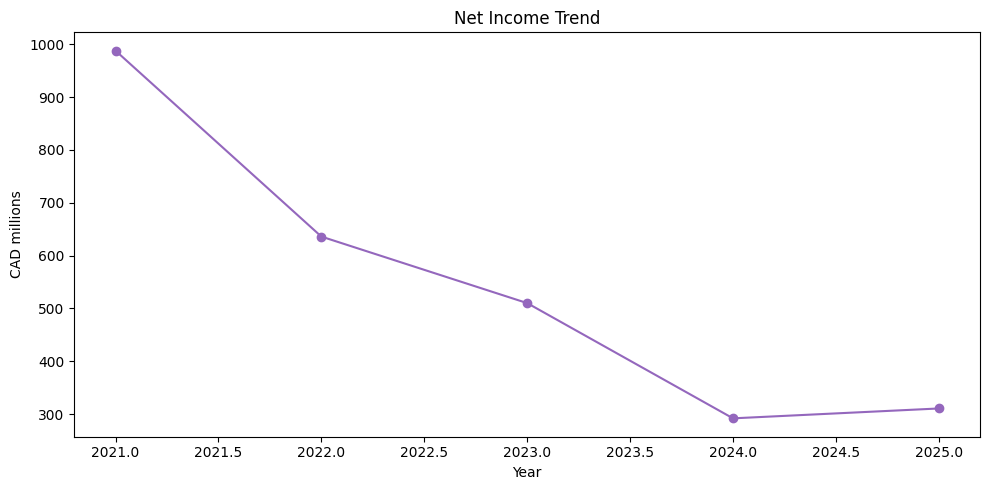

In [9]:
cashflow_table = pd.merge(
    operating_cash_flow[["period", "value"]].rename(columns={"value": "operating_cash_flow"}),
    distributions_paid[["period", "value"]].rename(columns={"value": "distributions_paid"}),
    on="period",
    how="outer",
).sort_values("period")
cashflow_table["distributions_paid_abs"] = cashflow_table["distributions_paid"].abs()
cashflow_table["distributions_as_pct_of_operating_cash_flow"] = (
    cashflow_table["distributions_paid_abs"] / cashflow_table["operating_cash_flow"] * 100
)
cashflow_table["operating_cash_flow_cad_millions"] = thousands_to_millions(cashflow_table["operating_cash_flow"])
cashflow_table["distributions_paid_cad_millions"] = thousands_to_millions(cashflow_table["distributions_paid_abs"])
display(cashflow_table)

plt.figure()
plt.plot(cashflow_table["period"], cashflow_table["operating_cash_flow_cad_millions"], marker="o", label="Operating cash flow")
plt.plot(cashflow_table["period"], cashflow_table["distributions_paid_cad_millions"], marker="o", label="Distributions paid")
plt.title("Operating Cash Flow vs Distributions Paid")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(net_income["period"], thousands_to_millions(net_income["value"]), marker="o", color="tab:purple")
plt.title("Net Income Trend")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.tight_layout()
plt.show()

## 5. Property and Operating Metrics

Property analysis uses `smartcentres_properties.csv`.

Occupancy is especially important for a REIT because it shows how much of the leasable portfolio is rented or committed.

,metric_or_line_item,period,value
0,Average lease term to maturity,2020,4.6
1,Average lease term to maturity,2021,4.4
2,Average lease term to maturity,2022,4.2
3,Average lease term to maturity,2023,4.3
4,Average lease term to maturity,2024,4.2
5,Average lease term to maturity,2025,4.3
6,"Gross leasable retail, office and industrial area",2023,35045.0
7,"Gross leasable retail, office and industrial area",2024,35300.0
8,"Gross leasable retail, office and industrial area",2025,35585.0
9,In-place and committed occupancy rate,2020,97.3


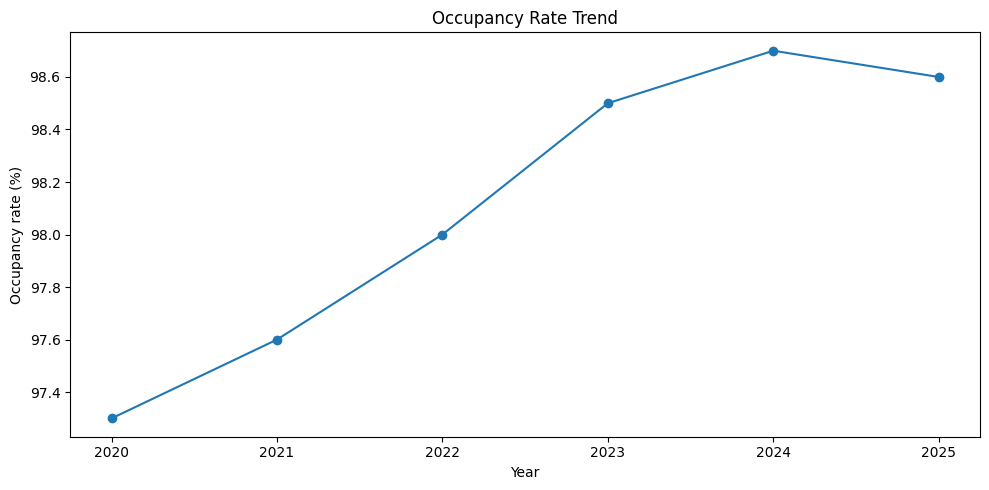

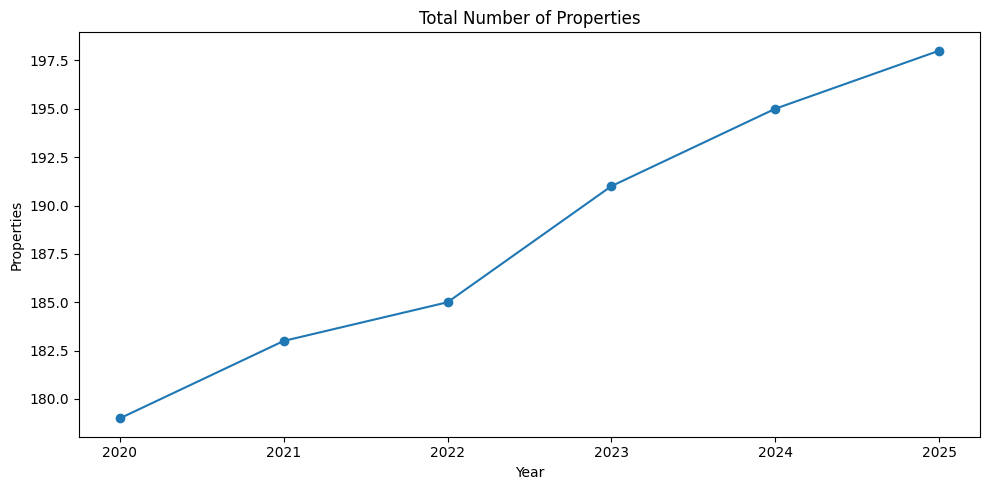

In [10]:
properties["period"] = pd.to_numeric(properties["period"], errors="coerce").astype("Int64")
properties["value_numeric"] = pd.to_numeric(properties["value_numeric"], errors="coerce")
property_summary = (
    properties.dropna(subset=["period", "metric_or_line_item", "value_numeric"])
    .groupby(["metric_or_line_item", "period"], as_index=False)
    .agg(value=("value_numeric", "median"))
    .sort_values(["metric_or_line_item", "period"])
)

occupancy = metric_series(property_summary, "In-place and committed occupancy rate")
property_count = metric_series(property_summary, "Total number of properties with an ownership interest")

display(property_summary.head(15))

plt.figure()
plt.plot(occupancy["period"], occupancy["value"], marker="o")
plt.title("Occupancy Rate Trend")
plt.xlabel("Year")
plt.ylabel("Occupancy rate (%)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(property_count["period"], property_count["value"], marker="o")
plt.title("Total Number of Properties")
plt.xlabel("Year")
plt.ylabel("Properties")
plt.tight_layout()
plt.show()

## 6. Competitor Snapshot

Competitor analysis uses:
- `wowa_competitors.csv` for WOWA yield/market-cap snapshot;
- `yfinance_company_profile.csv` for yfinance profile fields.

These sources may differ because they update at different times.

,REIT,Symbol (TSX),Type,Share Price,Market Cap,Yield,source,share_price_numeric,market_cap_numeric,yield_numeric
0,RioCan REIT,REI.UN,Retail,$21.90,$6.93 Billion,4.39%,WOWA,21.90,6.93,4.39
1,Allied Properties REIT,AP.UN,Office,$42.61,$5.45 Billion,3.97%,WOWA,42.61,5.45,3.97
2,Choice Properties REIT,CHP.UN,Commercial / Residential,$15.07,$4.87 Billion,4.97%,WOWA,15.07,4.87,4.97
3,SmartCentres REIT,SRU.UN,Retail,$30.00,$4.35 Billion,6.15%,WOWA,30.00,4.35,6.15
4,First Capital Realty,FCR.UN,Commercial,$17.65,$3.84 Billion,2.47%,WOWA,17.65,3.84,2.47


,ticker,shortName,marketCap,beta,dividendYield,fiftyTwoWeekHigh,fiftyTwoWeekLow
0,SRU-UN.TO,SMARTCENTRES REIT,5909043712,0.850,6.15,30.90,25.010
1,REI-UN.TO,RIOCAN REAL EST UN,6561352704,0.999,5.15,23.25,17.485
2,CHP-UN.TO,CHOICE PROPERTIES REIT,11899450368,0.781,4.74,16.87,14.090
3,AP-UN.TO,ALLIED PROPERTIES REAL ESTATE I,2129712128,1.090,7.05,22.27,8.740
4,FCR-UN.TO,FIRST CAPITAL REIT UNITS,4965284864,0.885,3.86,23.84,18.100


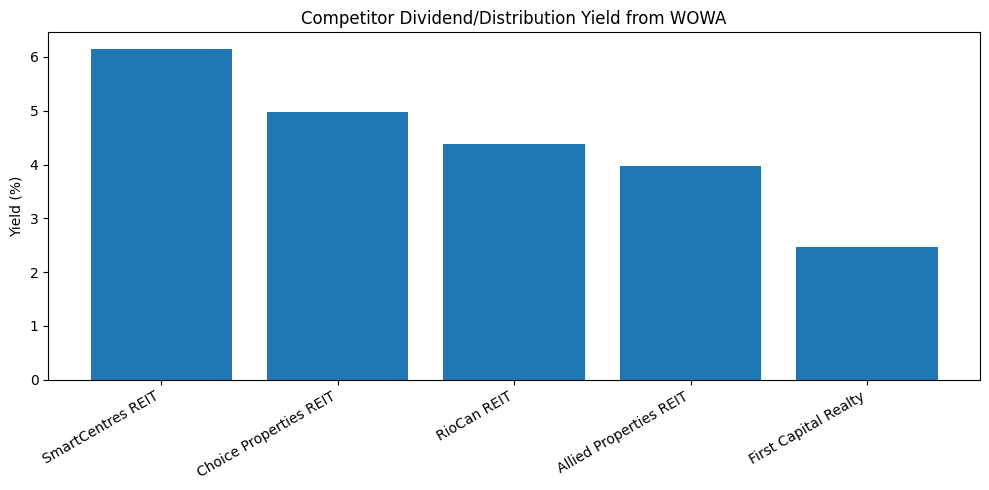

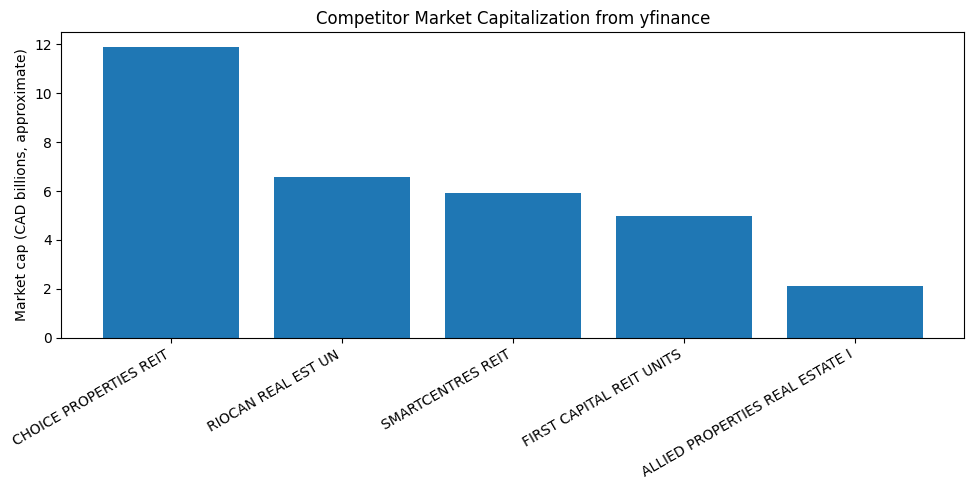

In [11]:
display(competitors)
display(company_profile[["ticker", "shortName", "marketCap", "beta", "dividendYield", "fiftyTwoWeekHigh", "fiftyTwoWeekLow"]])

plt.figure()
competitor_yields = competitors.sort_values("yield_numeric", ascending=False)
plt.bar(competitor_yields["REIT"], competitor_yields["yield_numeric"])
plt.xticks(rotation=30, ha="right")
plt.title("Competitor Dividend/Distribution Yield from WOWA")
plt.ylabel("Yield (%)")
plt.tight_layout()
plt.show()

plt.figure()
profiles = company_profile.copy()
profiles["market_cap_billions"] = profiles["marketCap"] / 1_000_000_000
profiles = profiles.sort_values("market_cap_billions", ascending=False)
plt.bar(profiles["shortName"], profiles["market_cap_billions"])
plt.xticks(rotation=30, ha="right")
plt.title("Competitor Market Capitalization from yfinance")
plt.ylabel("Market cap (CAD billions, approximate)")
plt.tight_layout()
plt.show()

## 7. Macroeconomic Context

Macro analysis uses `bank_of_canada_macro.csv`.

REITs are interest-rate-sensitive because they often use debt and because investors compare REIT distributions with safer bond yields.

,date,smartcentres_adj_close,monthly_return,10-year Government of Canada benchmark bond yield,5-year Government of Canada benchmark bond yield,Prime rate,Target overnight rate,Total CPI,Total CPI year-over-year change,USD/CAD exchange rate
0,2021-01-31,16.125237,NaN,0.84,0.43,2.45,0.25,138.2,1.0,1.2780
1,2021-02-28,18.120064,0.123708,1.35,0.88,2.45,0.25,138.9,1.1,1.2685
2,2021-03-31,18.611893,0.027143,1.55,0.99,2.45,0.25,139.6,2.2,1.2575
3,2021-04-30,19.946295,0.071696,1.54,0.93,2.45,0.25,140.3,3.4,1.2285
4,2021-05-31,20.527994,0.029163,1.49,0.90,2.45,0.25,141.0,3.6,1.2072


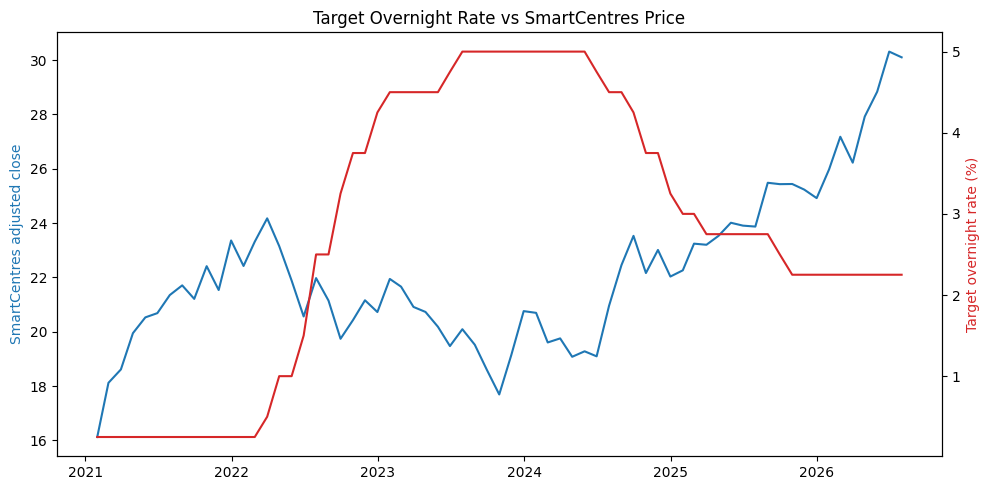

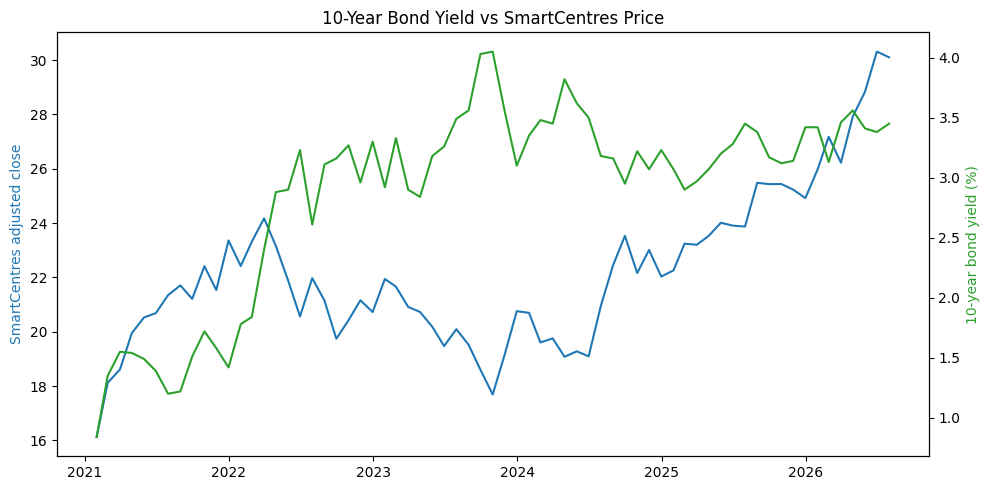

In [12]:
macro["date"] = pd.to_datetime(macro["date"], errors="coerce")
macro["value"] = pd.to_numeric(macro["value"], errors="coerce")

monthly_macro = (
    macro.set_index("date")
    .groupby("series_name")
    .resample("ME")["value"]
    .last()
    .reset_index()
    .pivot(index="date", columns="series_name", values="value")
    .reset_index()
)

smart_monthly = monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER][["Date", "Adj Close", "monthly_return"]].copy()
smart_monthly = smart_monthly.rename(columns={"Date": "date", "Adj Close": "smartcentres_adj_close"})
stock_macro = pd.merge(smart_monthly, monthly_macro, on="date", how="left")
display(stock_macro.head())

if "Target overnight rate" in stock_macro.columns:
    fig, ax1 = plt.subplots()
    ax1.plot(stock_macro["date"], stock_macro["smartcentres_adj_close"], color="tab:blue")
    ax1.set_ylabel("SmartCentres adjusted close", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(stock_macro["date"], stock_macro["Target overnight rate"], color="tab:red")
    ax2.set_ylabel("Target overnight rate (%)", color="tab:red")
    plt.title("Target Overnight Rate vs SmartCentres Price")
    plt.tight_layout()
    plt.show()

bond_col = "10-year Government of Canada benchmark bond yield"
if bond_col in stock_macro.columns:
    fig, ax1 = plt.subplots()
    ax1.plot(stock_macro["date"], stock_macro["smartcentres_adj_close"], color="tab:blue")
    ax1.set_ylabel("SmartCentres adjusted close", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(stock_macro["date"], stock_macro[bond_col], color="tab:green")
    ax2.set_ylabel("10-year bond yield (%)", color="tab:green")
    plt.title("10-Year Bond Yield vs SmartCentres Price")
    plt.tight_layout()
    plt.show()

,macro_variable,correlation_with_smartcentres_monthly_return
1,5-year Government of Canada benchmark bond yield,-0.318569
0,10-year Government of Canada benchmark bond yield,-0.281952
5,Total CPI year-over-year change,-0.218014
6,USD/CAD exchange rate,-0.160450
2,Prime rate,-0.151287
3,Target overnight rate,-0.145307
4,Total CPI,-0.090932


,year,annual_distribution_per_unit,year_end_adjusted_close,avg_5yr_bond_yield,estimated_dividend_yield,yield_spread
0,2021,1.848,23.358267,0.947671,7.911546,6.963875
1,2022,1.848,20.724630,2.774556,8.916926,6.142370
2,2023,1.848,20.758196,3.563226,8.902508,5.339282
3,2024,1.848,22.030838,3.302160,8.388242,5.086082
4,2025,1.848,24.917452,2.834056,7.416489,4.582432


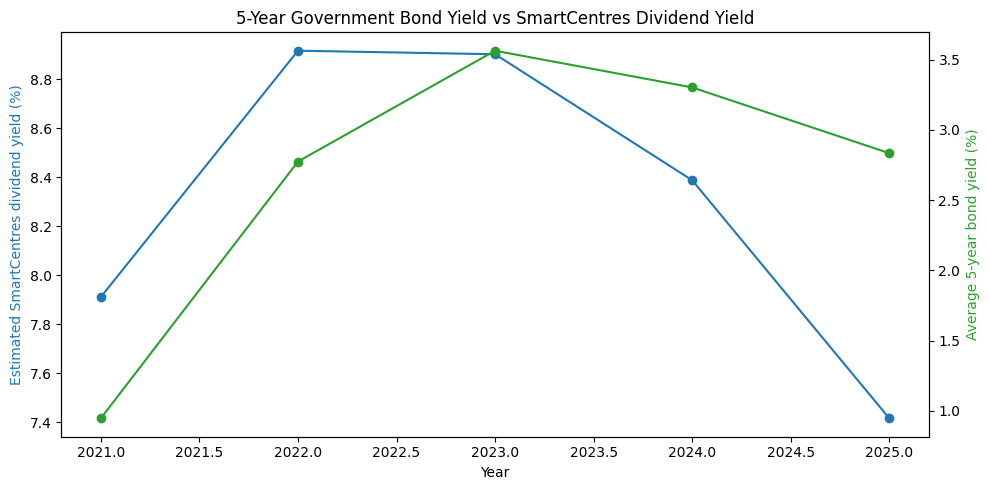

In [13]:
macro_columns = [c for c in stock_macro.columns if c not in ["date", "smartcentres_adj_close", "monthly_return"]]
correlations = []
for column in macro_columns:
    correlations.append({
        "macro_variable": column,
        "correlation_with_smartcentres_monthly_return": stock_macro["monthly_return"].corr(stock_macro[column]),
    })
macro_correlations = pd.DataFrame(correlations).sort_values("correlation_with_smartcentres_monthly_return")
display(macro_correlations)

# Bond yield vs dividend yield is useful for income investors.
# A REIT distribution has more risk than a government bond yield, so the
# spread helps frame whether the REIT income looks meaningfully higher.
annual_bond = (
    macro[macro["series_name"] == "5-year Government of Canada benchmark bond yield"]
    .assign(year=lambda df: df["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(avg_5yr_bond_yield=("value", "mean"))
)
smart_year_end = (
    monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER]
    .assign(year=lambda df: df["Date"].dt.year)
    .sort_values("Date")
    .groupby("year", as_index=False)
    .tail(1)[["year", "Adj Close"]]
    .rename(columns={"Adj Close": "year_end_adjusted_close"})
)
full_year_dividends = annual_dividends[annual_dividends["payment_count"] >= 12].copy()
bond_vs_dividend = pd.merge(full_year_dividends[["year", "annual_distribution_per_unit"]], smart_year_end, on="year", how="left")
bond_vs_dividend = pd.merge(bond_vs_dividend, annual_bond, on="year", how="left")
bond_vs_dividend["estimated_dividend_yield"] = (
    bond_vs_dividend["annual_distribution_per_unit"] / bond_vs_dividend["year_end_adjusted_close"] * 100
)
bond_vs_dividend["yield_spread"] = bond_vs_dividend["estimated_dividend_yield"] - bond_vs_dividend["avg_5yr_bond_yield"]
display(bond_vs_dividend)

fig, ax1 = plt.subplots()
ax1.plot(bond_vs_dividend["year"], bond_vs_dividend["estimated_dividend_yield"], marker="o", color="tab:blue")
ax1.set_ylabel("Estimated SmartCentres dividend yield (%)", color="tab:blue")
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
ax2.plot(bond_vs_dividend["year"], bond_vs_dividend["avg_5yr_bond_yield"], marker="o", color="tab:green")
ax2.set_ylabel("Average 5-year bond yield (%)", color="tab:green")
plt.title("5-Year Government Bond Yield vs SmartCentres Dividend Yield")
plt.tight_layout()
plt.show()

### Yield Spread Analysis

This chart visualizes the 'Yield Spread', which is the difference between the REIT's dividend yield and the 5-year Government of Canada bond yield. A wider spread often indicates the REIT is providing a significant risk premium over 'risk-free' government debt.

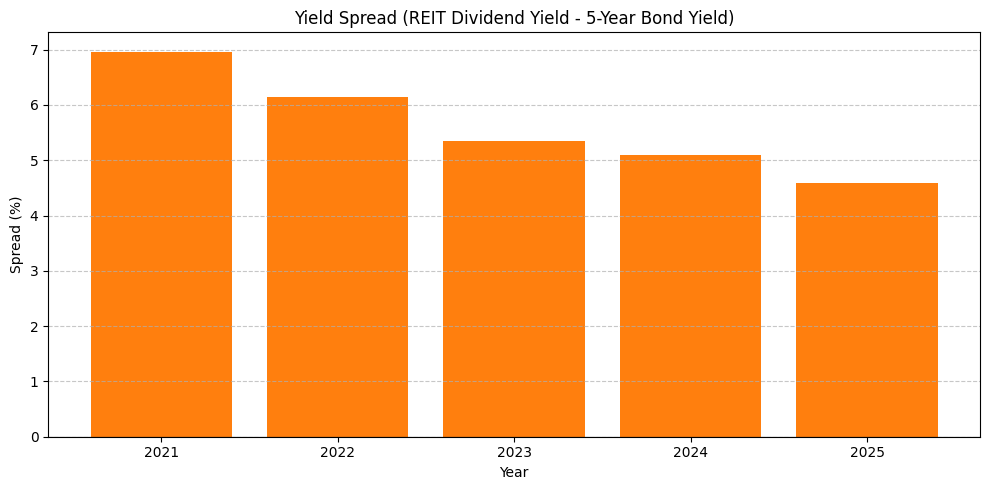

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(bond_vs_dividend["year"].astype(str), bond_vs_dividend["yield_spread"], color="tab:orange")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Yield Spread (REIT Dividend Yield - 5-Year Bond Yield)")
plt.xlabel("Year")
plt.ylabel("Spread (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()